In [7]:
!pip install PyPortfolioOpt yfinance scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
import os
import zipfile
warnings.filterwarnings('ignore')

from pypfopt import expected_returns, risk_models, EfficientFrontier, objective_functions
from pypfopt import plotting

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
os.makedirs('data/processed/', exist_ok=True)

print("=" * 60)
print("TASK 4: PORTFOLIO OPTIMIZATION BASED ON FORECAST")
print("=" * 60)

TASK 4: PORTFOLIO OPTIMIZATION BASED ON FORECAST


In [8]:
print("\n1. LOADING DATA...")

print("Fetching TSLA...")
tsla_raw = yf.download('TSLA', start='2015-01-01', end='2026-06-30', progress=False)

print("Fetching BND...")
bnd_raw = yf.download('BND', start='2015-01-01', end='2026-06-30', progress=False)

print("Fetching SPY...")
spy_raw = yf.download('SPY', start='2015-01-01', end='2026-06-30', progress=False)

tsla_close = tsla_raw['Close'].values.flatten()
bnd_close = bnd_raw['Close'].values.flatten()
spy_close = spy_raw['Close'].values.flatten()

tsla_series = pd.Series(tsla_close, index=tsla_raw.index, dtype=float)
bnd_series = pd.Series(bnd_close, index=bnd_raw.index, dtype=float)
spy_series = pd.Series(spy_close, index=spy_raw.index, dtype=float)

tsla_returns = tsla_series.pct_change().dropna()
bnd_returns = bnd_series.pct_change().dropna()
spy_returns = spy_series.pct_change().dropna()

returns_df = pd.DataFrame({
    'TSLA': tsla_returns,
    'BND': bnd_returns,
    'SPY': spy_returns
}).dropna()

print(f"Returns DataFrame shape: {returns_df.shape}")
print("\nFirst 5 rows:")
print(returns_df.head())


1. LOADING DATA...
Fetching TSLA...
Fetching BND...
Fetching SPY...
Returns DataFrame shape: (2887, 3)

First 5 rows:
                TSLA       BND       SPY
Date                                    
2015-01-05 -0.042041  0.002903 -0.018060
2015-01-06  0.005664  0.002896 -0.009419
2015-01-07 -0.001562  0.000602  0.012461
2015-01-08 -0.001564 -0.001563  0.017744
2015-01-09 -0.018802  0.001686 -0.008013


In [9]:
print("\n2. LOADING FORECAST DATA...")

try:
    forecast_df = pd.read_csv('data/processed/future_forecast.csv', parse_dates=['Date'])

    forecast_start = forecast_df['Price'].iloc[0]
    forecast_end = forecast_df['Price'].iloc[-1]
    tsla_expected_return = (forecast_end / forecast_start) - 1

    print(f"TSLA Forecast Start Price: ${forecast_start:.2f}")
    print(f"TSLA Forecast End Price: ${forecast_end:.2f}")
    print(f"TSLA Expected Return (from forecast): {tsla_expected_return:.2%}")

except FileNotFoundError:
    print("Forecast file not found. Using historical returns for TSLA...")
    tsla_expected_return = returns_df['TSLA'].mean() * 252
    print(f"TSLA Expected Return (historical): {tsla_expected_return:.2%}")

bnd_expected_return = returns_df['BND'].mean() * 252
spy_expected_return = returns_df['SPY'].mean() * 252

print(f"\nBND Expected Return (annualized): {bnd_expected_return:.2%}")
print(f"SPY Expected Return (annualized): {spy_expected_return:.2%}")

expected_returns_dict = {
    'TSLA': tsla_expected_return,
    'BND': bnd_expected_return,
    'SPY': spy_expected_return
}

print("\nExpected Returns Vector:")
for asset, ret in expected_returns_dict.items():
    print(f"  {asset}: {ret:.2%}")


2. LOADING FORECAST DATA...
Forecast file not found. Using historical returns for TSLA...
TSLA Expected Return (historical): 45.42%

BND Expected Return (annualized): 2.00%
SPY Expected Return (annualized): 14.43%

Expected Returns Vector:
  TSLA: 45.42%
  BND: 2.00%
  SPY: 14.43%


In [10]:
print("\n3. COMPUTING COVARIANCE MATRIX...")

cov_matrix = returns_df.cov() * 252
corr_matrix = returns_df.corr()

print("Covariance Matrix (Annualized):")
print(cov_matrix)

print("\nCorrelation Matrix:")
print(corr_matrix)


3. COMPUTING COVARIANCE MATRIX...
Covariance Matrix (Annualized):
          TSLA       BND       SPY
TSLA  0.326926  0.001803  0.049820
BND   0.001803  0.002823  0.001085
SPY   0.049820  0.001085  0.031169

Correlation Matrix:
          TSLA       BND       SPY
TSLA  1.000000  0.059361  0.493535
BND   0.059361  1.000000  0.115709
SPY   0.493535  0.115709  1.000000



4. VISUALIZING COVARIANCE AND CORRELATION...


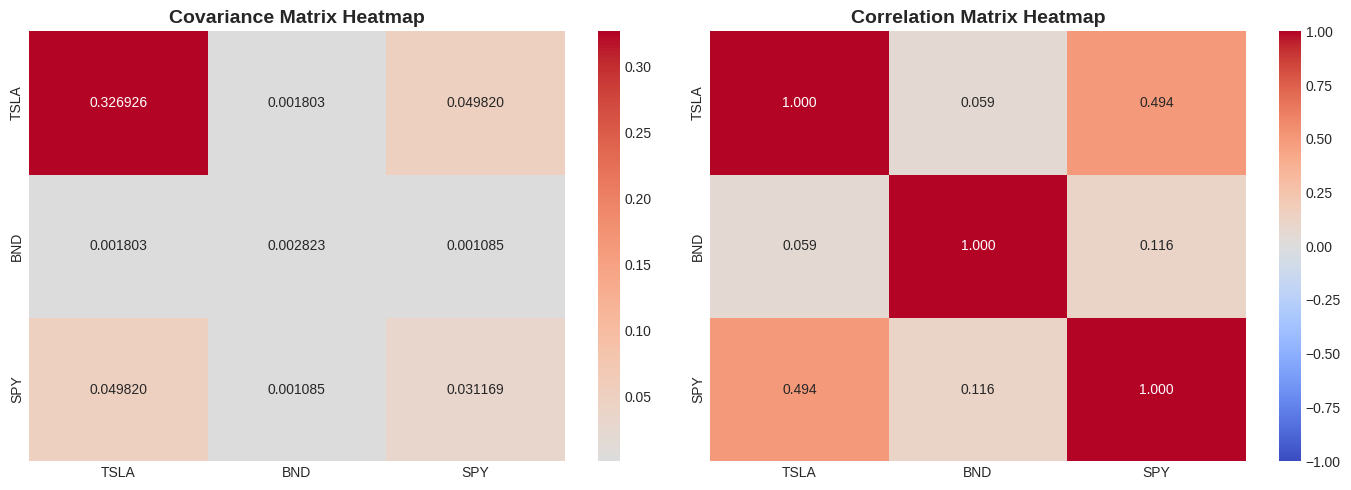

Saved: data/processed/covariance_heatmap.png


In [11]:
print("\n4. VISUALIZING COVARIANCE AND CORRELATION...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cov_matrix, annot=True, fmt='.6f', cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Covariance Matrix Heatmap', fontsize=14, fontweight='bold')

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/covariance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: data/processed/covariance_heatmap.png")

In [12]:
print("\n5. GENERATING EFFICIENT FRONTIER...")

assets = ['TSLA', 'BND', 'SPY']
mu = np.array([expected_returns_dict[asset] for asset in assets])

# Create Efficient Frontier
ef = EfficientFrontier(mu, cov_matrix)

# Generate efficient frontier points - FIXED METHOD
frontier_returns = []
frontier_volatilities = []
frontier_weights = []

# Generate points along the efficient frontier
for target_return in np.linspace(mu.min(), mu.max(), 50):
    ef_temp = EfficientFrontier(mu, cov_matrix)
    try:
        ef_temp.efficient_return(target_return)
        ret, vol, _ = ef_temp.portfolio_performance(risk_free_rate=0.02)
        frontier_returns.append(ret)
        frontier_volatilities.append(vol)
        frontier_weights.append(ef_temp.weights)
    except:
        continue

print(f"Efficient Frontier generated successfully")
print(f"Number of portfolios on frontier: {len(frontier_returns)}")


5. GENERATING EFFICIENT FRONTIER...
Efficient Frontier generated successfully
Number of portfolios on frontier: 49


In [13]:
print("\n6. FINDING OPTIMAL PORTFOLIOS...")

# Find maximum Sharpe ratio portfolio
ef_max_sharpe = EfficientFrontier(mu, cov_matrix)
ef_max_sharpe.max_sharpe(risk_free_rate=0.02)
max_sharpe_weights = ef_max_sharpe.clean_weights()
max_sharpe_ret, max_sharpe_vol, max_sharpe_sharpe = ef_max_sharpe.portfolio_performance(risk_free_rate=0.02)

# Find minimum volatility portfolio
ef_min_vol = EfficientFrontier(mu, cov_matrix)
ef_min_vol.min_volatility()
min_vol_weights = ef_min_vol.clean_weights()
min_vol_ret, min_vol_vol, min_vol_sharpe = ef_min_vol.portfolio_performance(risk_free_rate=0.02)

print("Maximum Sharpe Ratio Portfolio (Tangency Portfolio):")
for asset, weight in max_sharpe_weights.items():
    if weight > 0.001:
        print(f"  {asset}: {weight:.2%}")

print(f"\nExpected Return: {max_sharpe_ret:.2%}")
print(f"Expected Volatility: {max_sharpe_vol:.2%}")
print(f"Sharpe Ratio: {max_sharpe_sharpe:.3f}")

print("\nMinimum Volatility Portfolio:")
for asset, weight in min_vol_weights.items():
    if weight > 0.001:
        print(f"  {asset}: {weight:.2%}")

print(f"\nExpected Return: {min_vol_ret:.2%}")
print(f"Expected Volatility: {min_vol_vol:.2%}")
print(f"Sharpe Ratio: {min_vol_sharpe:.3f}")


6. FINDING OPTIMAL PORTFOLIOS...
Maximum Sharpe Ratio Portfolio (Tangency Portfolio):
  TSLA: 27.86%
  SPY: 72.14%

Expected Return: 23.07%
Expected Volatility: 24.82%
Sharpe Ratio: 0.849

Minimum Volatility Portfolio:
  BND: 94.54%
  SPY: 5.46%

Expected Return: 2.67%
Expected Volatility: 5.22%
Sharpe Ratio: 0.129



7. PLOTTING EFFICIENT FRONTIER...


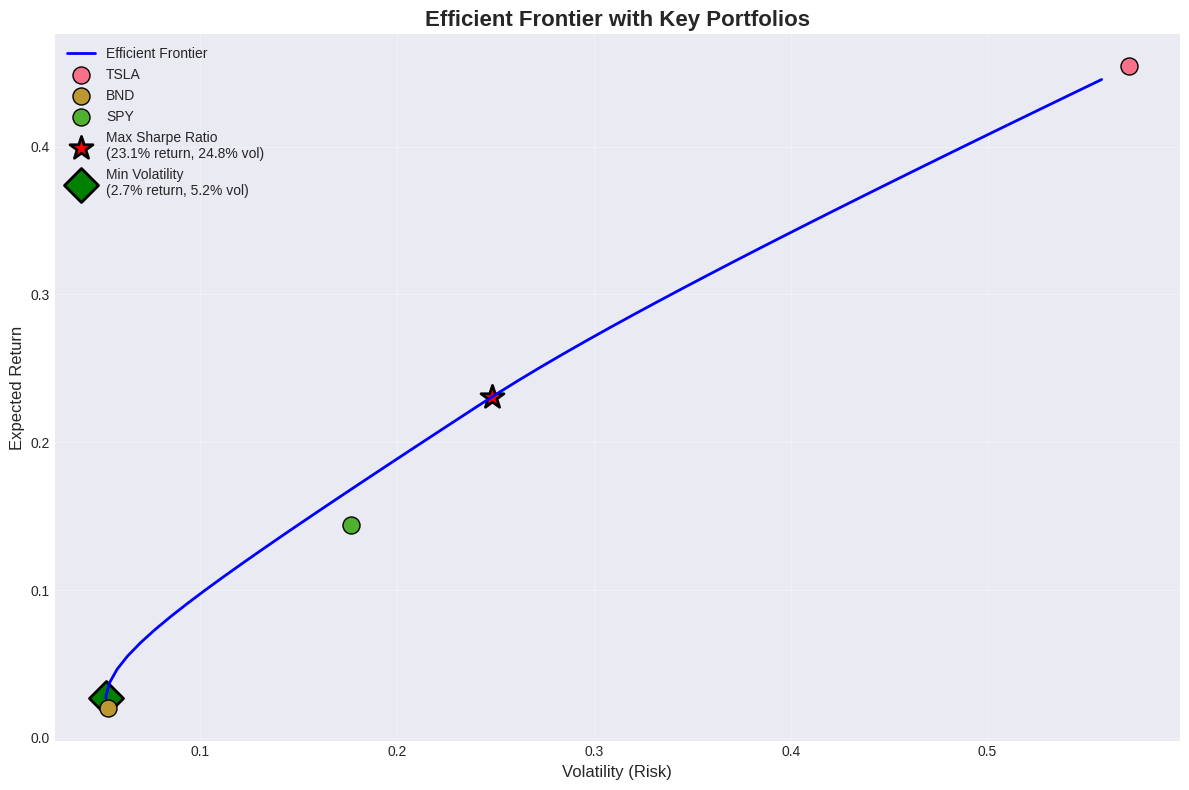

Saved: data/processed/efficient_frontier.png


In [14]:
print("\n7. PLOTTING EFFICIENT FRONTIER...")

fig, ax = plt.subplots(figsize=(12, 8))

# Plot efficient frontier
if len(frontier_returns) > 0:
    ax.plot(frontier_volatilities, frontier_returns, 'b-', linewidth=2, label='Efficient Frontier')

# Plot individual assets
asset_volatility = np.sqrt(np.diag(cov_matrix))
for i, asset in enumerate(assets):
    ax.scatter(asset_volatility[i], mu[i], s=150, label=asset, zorder=5, edgecolors='black')

# Mark Max Sharpe portfolio
ax.scatter(max_sharpe_vol, max_sharpe_ret, s=300, color='red', marker='*',
          label=f'Max Sharpe Ratio\n({max_sharpe_ret:.1%} return, {max_sharpe_vol:.1%} vol)',
          edgecolors='black', linewidth=2)

# Mark Min Volatility portfolio
ax.scatter(min_vol_vol, min_vol_ret, s=300, color='green', marker='D',
          label=f'Min Volatility\n({min_vol_ret:.1%} return, {min_vol_vol:.1%} vol)',
          edgecolors='black', linewidth=2)

ax.set_xlabel('Volatility (Risk)', fontsize=12)
ax.set_ylabel('Expected Return', fontsize=12)
ax.set_title('Efficient Frontier with Key Portfolios', fontsize=16, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/efficient_frontier.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: data/processed/efficient_frontier.png")

In [15]:
print("\n8. PORTFOLIO DETAILS...")

portfolio_data = {
    'Portfolio': ['Max Sharpe Ratio', 'Min Volatility'],
    'TSLA Weight': [max_sharpe_weights.get('TSLA', 0), min_vol_weights.get('TSLA', 0)],
    'BND Weight': [max_sharpe_weights.get('BND', 0), min_vol_weights.get('BND', 0)],
    'SPY Weight': [max_sharpe_weights.get('SPY', 0), min_vol_weights.get('SPY', 0)],
    'Expected Return': [max_sharpe_ret, min_vol_ret],
    'Expected Volatility': [max_sharpe_vol, min_vol_vol],
    'Sharpe Ratio': [max_sharpe_sharpe, min_vol_sharpe]
}

portfolio_df = pd.DataFrame(portfolio_data)

print("Portfolio Comparison:")
print("=" * 80)
print(portfolio_df.to_string(index=False))

portfolio_df.to_csv('data/processed/portfolio_recommendations.csv', index=False)
print("\nSaved: data/processed/portfolio_recommendations.csv")


8. PORTFOLIO DETAILS...
Portfolio Comparison:
       Portfolio  TSLA Weight  BND Weight  SPY Weight  Expected Return  Expected Volatility  Sharpe Ratio
Max Sharpe Ratio      0.27859     0.00000     0.72141         0.230660             0.248233      0.848637
  Min Volatility      0.00000     0.94538     0.05462         0.026749             0.052235      0.129208

Saved: data/processed/portfolio_recommendations.csv


In [16]:
print("\n9. FINAL RECOMMENDATION...")

if max_sharpe_sharpe > min_vol_sharpe * 1.1:
    recommended = 'Max Sharpe Ratio Portfolio'
    weights = max_sharpe_weights
    ret, vol, sharpe = max_sharpe_ret, max_sharpe_vol, max_sharpe_sharpe
else:
    recommended = 'Minimum Volatility Portfolio'
    weights = min_vol_weights
    ret, vol, sharpe = min_vol_ret, min_vol_vol, min_vol_sharpe

print("=" * 60)
print("FINAL PORTFOLIO RECOMMENDATION")
print("=" * 60)

print(f"\nRecommended Portfolio: {recommended}")

print("\nRationale:")
if recommended == 'Max Sharpe Ratio Portfolio':
    print("  - This portfolio offers the best risk-adjusted returns")
    print("  - Higher Sharpe ratio indicates better compensation for risk")
    print("  - Suitable for investors with moderate to high risk tolerance")
else:
    print("  - This portfolio minimizes overall volatility")
    print("  - Suitable for conservative investors prioritizing capital preservation")
    print("  - Lower risk profile with stable returns")

print(f"\nPortfolio Weights:")
for asset, weight in weights.items():
    if weight > 0.001:
        print(f"  {asset}: {weight:.2%}")

print(f"\nExpected Annual Return: {ret:.2%}")
print(f"Expected Annual Volatility: {vol:.2%}")
print(f"Sharpe Ratio: {sharpe:.3f}")

recommendation_data = {
    'Recommended_Portfolio': recommended,
    'TSLA_Weight': weights.get('TSLA', 0),
    'BND_Weight': weights.get('BND', 0),
    'SPY_Weight': weights.get('SPY', 0),
    'Expected_Return': ret,
    'Expected_Volatility': vol,
    'Sharpe_Ratio': sharpe
}

recommendation_df = pd.DataFrame([recommendation_data])
recommendation_df.to_csv('data/processed/final_portfolio_recommendation.csv', index=False)
print("\nSaved: data/processed/final_portfolio_recommendation.csv")


9. FINAL RECOMMENDATION...
FINAL PORTFOLIO RECOMMENDATION

Recommended Portfolio: Max Sharpe Ratio Portfolio

Rationale:
  - This portfolio offers the best risk-adjusted returns
  - Higher Sharpe ratio indicates better compensation for risk
  - Suitable for investors with moderate to high risk tolerance

Portfolio Weights:
  TSLA: 27.86%
  SPY: 72.14%

Expected Annual Return: 23.07%
Expected Annual Volatility: 24.82%
Sharpe Ratio: 0.849

Saved: data/processed/final_portfolio_recommendation.csv



10. EXPECTED RETURNS COMPARISON...


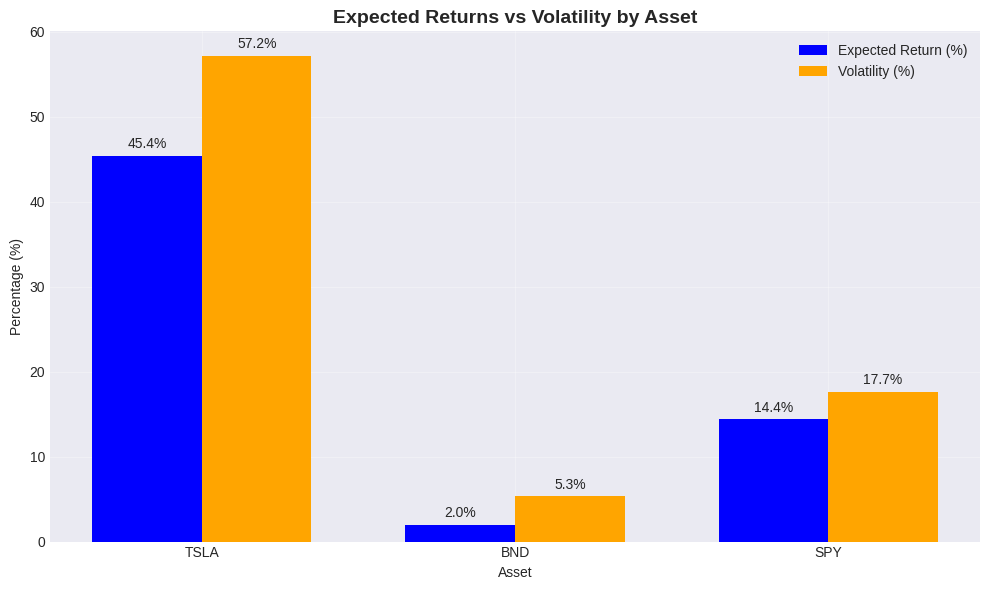

Saved: data/processed/expected_returns_comparison.png


In [17]:
print("\n10. EXPECTED RETURNS COMPARISON...")

comparison_data = {
    'Asset': ['TSLA', 'BND', 'SPY'],
    'Expected Return': [
        expected_returns_dict['TSLA'],
        expected_returns_dict['BND'],
        expected_returns_dict['SPY']
    ],
    'Volatility': [
        np.sqrt(cov_matrix.loc['TSLA', 'TSLA']),
        np.sqrt(cov_matrix.loc['BND', 'BND']),
        np.sqrt(cov_matrix.loc['SPY', 'SPY'])
    ]
}

comparison_df = pd.DataFrame(comparison_data)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df['Asset']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Expected Return'] * 100, width, label='Expected Return (%)', color='blue')
bars2 = ax.bar(x + width/2, comparison_df['Volatility'] * 100, width, label='Volatility (%)', color='orange')

ax.set_xlabel('Asset')
ax.set_ylabel('Percentage (%)')
ax.set_title('Expected Returns vs Volatility by Asset', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Asset'])
ax.legend()
ax.grid(True, alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.savefig('data/processed/expected_returns_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: data/processed/expected_returns_comparison.png")

In [18]:
print("\n11. DOWNLOADING RESULTS...")

with zipfile.ZipFile('task4_results.zip', 'w') as zipf:
    for file in os.listdir('data/processed/'):
        if file.endswith('.png') or file.endswith('.csv'):
            zipf.write(f'data/processed/{file}', file)

from google.colab import files
files.download('task4_results.zip')
print("Downloaded: task4_results.zip")


11. DOWNLOADING RESULTS...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: task4_results.zip


In [19]:
print("\n" + "=" * 60)
print("TASK 4 COMPLETE!")
print("=" * 60)

print("\nPortfolio Optimization Summary:")
print(f"\nRecommended Portfolio: {recommended}")
print(f"\nWeights:")
for asset, weight in weights.items():
    if weight > 0.001:
        print(f"  {asset}: {weight:.2%}")

print(f"\nExpected Annual Return: {ret:.2%}")
print(f"Expected Annual Volatility: {vol:.2%}")
print(f"Sharpe Ratio: {sharpe:.3f}")

print("\nKey Insights:")
print("  - TSLA provides high return potential but higher risk")
print("  - BND provides stability and income")
print("  - SPY provides diversified market exposure")
print("  - The optimal portfolio balances risk and return")

print("\nFiles Created:")
print("  - covariance_heatmap.png")
print("  - efficient_frontier.png")
print("  - expected_returns_comparison.png")
print("  - portfolio_recommendations.csv")
print("  - final_portfolio_recommendation.csv")
print("  - task4_results.zip")


TASK 4 COMPLETE!

Portfolio Optimization Summary:

Recommended Portfolio: Max Sharpe Ratio Portfolio

Weights:
  TSLA: 27.86%
  SPY: 72.14%

Expected Annual Return: 23.07%
Expected Annual Volatility: 24.82%
Sharpe Ratio: 0.849

Key Insights:
  - TSLA provides high return potential but higher risk
  - BND provides stability and income
  - SPY provides diversified market exposure
  - The optimal portfolio balances risk and return

Files Created:
  - covariance_heatmap.png
  - efficient_frontier.png
  - expected_returns_comparison.png
  - portfolio_recommendations.csv
  - final_portfolio_recommendation.csv
  - task4_results.zip
